<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_3-WorkGroupProyects/blob/main/week_3/src/AMGD_CP_W3_E3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Trabajo 3: Ejercicio de Aplicacion Autónoma

## 📋 Información del Proyecto
- Autores:
  - CARRERA DIAZ CHRISTIAN JAVIER
  - CERNA PACHECO ROMEL MICHAEL
  - LUNA ARTEAGA ALEXANDER PAUL
- Versión: 1.0.0
- Licencia: MIT


🎯 Introducción:

Consolidar los conceptos de limpieza y transformación de datos, prevención de data
leakage y diseño de pipelines reproducibles, integrando herramientas programáticas
como Python y entornos visuales como Orange Data Mining. Para el desarrollo del
trabajo, se recomienda utilizar Google Colab, que permite escribir y ejecutar código
Python en la nube desde el navegador web, así como integrar bloques de texto en
formato Markdown para la documentación técnica y metodológica.
La entrega debe incluir un único documento tipo notebook en formato .ipynb, junto con
los archivos adicionales solicitados en la actividad. El nombre del archivo debe seguir
estrictamente el formato: “AMGD_CP_W3_E#”, donde “#” corresponde al número de
equipo. Adicionalmente, se deberá adjuntar un documento en Word que contenga las
capturas del modelo desarrollado en Orange y una síntesis de las principales
discusiones, decisiones metodológicas y resultados obtenidos.

**🌍 Contexto del trabajo**

Los estudiantes deberán seleccionar un dataset público o una API de su interés
(preferiblemente relacionada con su área de estudio o trabajo). El objetivo es obtener datos
de esta fuente, realizar un proceso de limpieza y exploración inicial, y luego aplicar
transformaciones para realizar las validaciones realizadas en la arquitectura de orange.

# 1️⃣ Fase 1: Análisis en Python (Pipeline Profesional):

*******************************************************************************

## 🎯 **1.1. Objetivo general del proyecto**

Evaluar el impacto metodológico del uso correcto e incorrecto del preprocesamiento de datos en un problema de clasificación aplicado al dataset de vehículos nuevos registrados en el Servicio de Rentas Internas, mediante validación cruzada y comparación de métricas de desempeño.

##📌 **1.2. Justificación del proyecto**

Para este proyecto decidimos evidenciar cómo el diseño correcto del preprocesamiento impacta la validez y confiabilidad de los modelos de clasificación. Al comparar un enfoque con posible data leakage frente a uno basado en Pipeline y validación cruzada, se busca demostrar diferencias reales en desempeño y generalización. El análisis aplicado al dataset de vehículos del SRI permite integrar fundamentos metodológicos con un caso práctico. Así, se refuerzan buenas prácticas en arquitectura y reproducibilidad en Ciencia de Datos.

## ✅ **1.3. Objetivos específicos**

1️⃣ Seleccionar un dataset estructurado de clasificación
- Utilizar el dataset de vehículos nuevos registrados en el SRI.
- Garantizar un mínimo de 10 variables predictoras.
- Definir claramente la variable objetivo (por ejemplo: tipo de vehículo, segmento, categoría de precio, tipo de combustible, etc.).

2️⃣ Realizar análisis exploratorio de datos (EDA)
- Analizar la distribución de variables numéricas y categóricas.
- Identificar valores faltantes y evaluar su tratamiento.
- Detectar posibles outliers y su impacto en el modelado.
- Examinar correlaciones preliminares entre variables.

3️⃣ Implementar dos enfoques de modelado

- Enfoque metodológicamente incorrecto

  - Aplicar transformaciones (normalización, imputación, selección de variables) antes de la validación cruzada.
  - Evidenciar posible data leakage.

- Enfoque metodológicamente correcto

  - Construir un Pipeline de sklearn que incluya:
  - Preprocesamiento (imputación, escalado, codificación).
  - Modelo de clasificación.
  - Integrar todo el flujo dentro de la validación cruzada.  

4️⃣ Comparar métricas de desempeño

- Utilizar validación cruzada (k-fold).
- Comparar métricas como:
  - Accuracy
  - Precision
  - Recall
  - F1-score
- Analizar estabilidad de resultados (media y desviación estándar).

5️⃣ Analizar resultados y explicar el impacto arquitectónico

- Evaluar diferencias en desempeño entre ambos enfoques.
- Identificar evidencia de data leakage.
- Explicar la importancia del diseño arquitectónico del pipeline en términos de:
  - Reproducibilidad.
  - Generalización.
  - Integridad experimental.
  - Buenas prácticas en MLOps.

## 🔗 1.4. Enlaces del Dataset que se usaran

La información usada esta en la pagina oficial del INEC https://www.censoecuador.gob.ec/data-censo-ecuador/ que nos ofrece el dataset con todos sus complementos como la encuenta realizada, el diccionario de datos, etc.

- Dataset del registro de vehiculos nuevos registrados por el SRI 2025: https://www.sri.gob.ec/datasets#Ventas%20-%20Compras


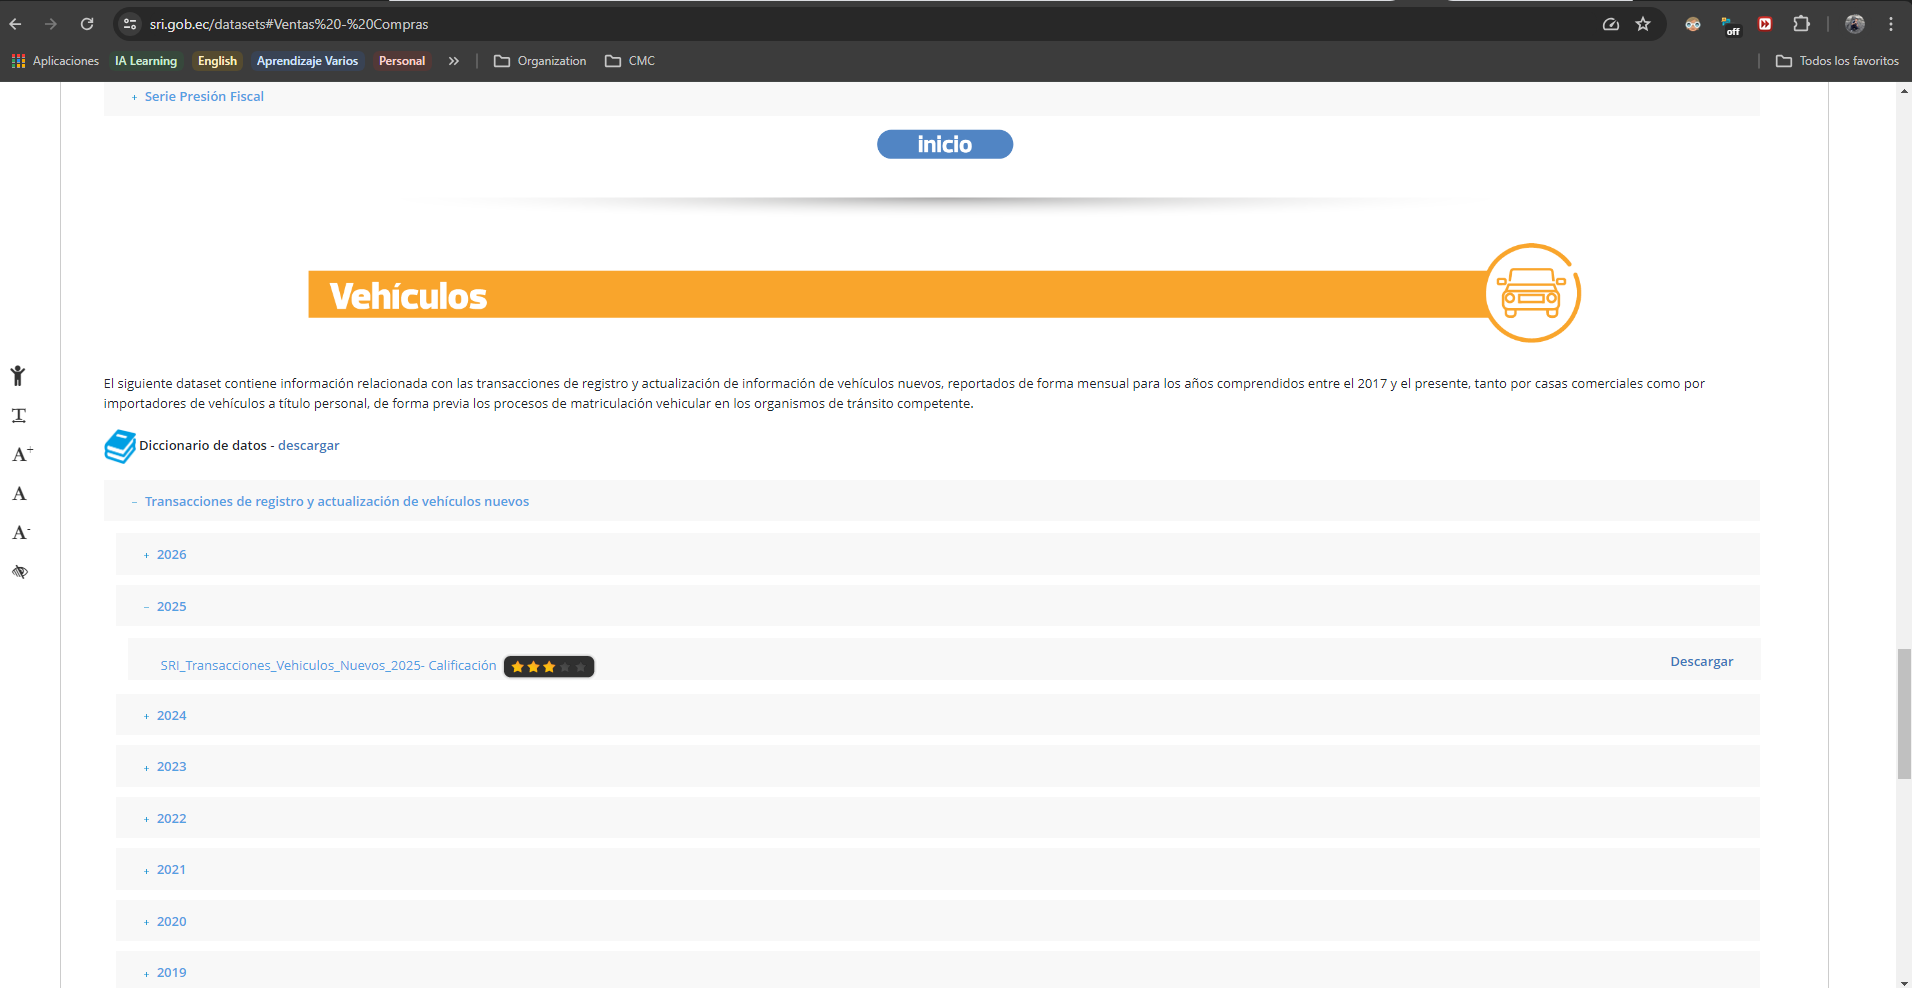




## 🚀 1.5. Descarga del dataset

El dataset contiene información relacionada con las transacciones de registro y actualización de información de vehículos nuevos, reportados de forma mensual para los años comprendidos entre el 2017 y el presente, tanto por casas comerciales como por importadores de vehículos a título personal, de forma previa los procesos de matriculación vehicular en los organismos de tránsito competente.

📥 Este código descarga un archivo csv y seleccionamos el dataset de vehiculos nuevos registrados por el SRI.

In [6]:
 # importacion de la libreria os que permite interactuar con el sistema operativo (archivos y rutas)

import os
import pandas as pd

# Define el nombre del archivo comprimido que se descargará
bought_sold_cars = 'Bought_Sold_Cars2025.csv'

# Descarga el archivo csv del sitio oficial del SRI
# El archivo se guarda en el entorno de trabajo actual y valido que si existe no lo descargue de nuevo

if not os.path.exists(bought_sold_cars) and not os.path.exists(bought_sold_cars):
  !wget --timeout=15 --tries=2 'https://descargas.sri.gob.ec/download/datosAbiertos/SRI_Vehiculos_Nuevos_2025.csv' -O '{bought_sold_cars}'
  # Validamos si se descargo el archivo sino vamos por otra alternativa
while True:
  try:
      # Leer el archivo
      df = pd.read_csv(bought_sold_cars, sep=';',encoding='latin-1')
      # Verificar si el DataFrame está vacío
      if df.empty:
          !wget 'https://github.com/ChrisJavier/UIDE_3-WorkGroupProyects/raw/refs/heads/main/week_3/src/Bought_Sold_Cars2025.csv' -O '{bought_sold_cars}'
      else:
          print("CSV válido")
          break
  except Exception as e:
      !wget 'https://github.com/ChrisJavier/UIDE_3-WorkGroupProyects/raw/refs/heads/main/week_3/src/Bought_Sold_Cars2025.csv' -O '{bought_sold_cars}'
      print(f"Error al leer el archivo CSV, {e}")



--2026-02-24 13:34:06--  https://descargas.sri.gob.ec/download/datosAbiertos/SRI_Vehiculos_Nuevos_2025.csv
Resolving descargas.sri.gob.ec (descargas.sri.gob.ec)... 190.152.216.15
Connecting to descargas.sri.gob.ec (descargas.sri.gob.ec)|190.152.216.15|:443... connected.
HTTP request sent, awaiting response... Read error (Connection reset by peer) in headers.
Retrying.

--2026-02-24 13:34:13--  (try: 2)  https://descargas.sri.gob.ec/download/datosAbiertos/SRI_Vehiculos_Nuevos_2025.csv
Connecting to descargas.sri.gob.ec (descargas.sri.gob.ec)|190.152.216.15|:443... connected.
HTTP request sent, awaiting response... Read error (Connection reset by peer) in headers.
Giving up.

--2026-02-24 13:34:18--  https://github.com/ChrisJavier/UIDE_3-WorkGroupProyects/raw/refs/heads/main/week_3/src/Bought_Sold_Cars2025.csv
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Locati

## 🚀 2.2. Previsualizacion y validacion

📥 Carga el dataset desde un archivo CSV comprimido, valida que tenga al menos 10.000 registros y muestra un resumen estadístico de sus columnas numéricas.

In [7]:
# Visualizamos un breve informacion del dataset
df.info()

# Valida que el dataset tenga al menos 10.000 registros, como solicita el ejercicio
if df.shape[0] < 10000:
    # Lanza una excepción si no se cumple el mínimo de registros
    raise Exception
else:
  # Muestra un mensaje de confirmación si el dataset es válido
  print(f'Dataset validado, el dataset contiene {df.shape[0]} registros \n')

# Muestra un resumen estadístico de las columnas numéricas del dataset
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482754 entries, 0 to 482753
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   CATEGORÍA                   482754 non-null  int64 
 1   CÓDIGO DE VEHÍCULO          482754 non-null  int64 
 2   TIPO TRANSACCIÓN            482754 non-null  object
 3   MARCA                       482754 non-null  object
 4   MODELO                      482754 non-null  object
 5   PAIS                        482754 non-null  object
 6   AÑO MODELO                  482754 non-null  int64 
 7   CLASE                       482754 non-null  object
 8   SUB CLASE                   482754 non-null  object
 9   TIPO                        482754 non-null  object
 10  AVALUO                      482754 non-null  object
 11  FECHA PROCESO (DD/MM/AAAA)  482754 non-null  object
 12  TIPO SERVICIO               482754 non-null  object
 13  CILINDRAJE                  4

,CATEGORÍA,CÓDIGO DE VEHÍCULO,AÑO MODELO,CILINDRAJE,CANTÓN
count,482754.000000,4.827540e+05,482754.000000,482754.000000,482754.000000
mean,94519.796329,9.964513e+06,2025.404401,869.634953,16414.136349
std,9294.228519,3.384611e+05,0.842111,1420.289536,6177.740167
min,29.000000,1.920717e+06,1979.000000,0.000000,10701.000000
25%,90034.000000,9.822290e+06,2025.000000,149.000000,10927.000000
50%,98577.000000,9.997460e+06,2026.000000,200.000000,11321.000000
75%,99980.000000,1.018095e+07,2026.000000,1494.000000,21701.000000
max,104856.000000,1.049422e+07,2027.000000,18037.000000,42003.000000


## 🚀 2.3. Transformacion de datos

🔍 Cambio de valores de las primeras tres columnas con los valores de la columnas provincia, canton y parroquia

In [11]:
# Adecuamos las columnas colocandole nombres en minusculas y sin caracteres especiales
import unicodedata

def quitar_tildes(texto):
    texto_normalizado = unicodedata.normalize('NFD', texto)
    texto_sin_tildes = ''.join(
        c for c in texto_normalizado
        if unicodedata.category(c) != 'Mn'
    )
    return texto_sin_tildes

texto = "Canción, acción, pingüino, información"
print(quitar_tildes(texto))

df.columns = [quitar_tildes(col).lower().rstrip().replace(' ','_').replace('_(dd/mm/aaaa)','').replace('-','') for col in df.columns]

# Convertimos los tipos de datos de las columnas necesarias

df['fecha_compra'] = pd.to_datetime(df['fecha_compra'])
df['fecha_proceso'] = pd.to_datetime(df['fecha_proceso'])

# Visualizacion de los nuevos datos
df.info()

# Visualizacion de los 10 primeros numeros
df.head(10)

Cancion, accion, pinguino, informacion


/tmp/ipython-input-223473830.py:19: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['fecha_compra'] = pd.to_datetime(df['fecha_compra'])
/tmp/ipython-input-223473830.py:20: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['fecha_proceso'] = pd.to_datetime(df['fecha_proceso'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482754 entries, 0 to 482753
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   categoria                  482754 non-null  int64         
 1   codigo_de_vehiculo         482754 non-null  int64         
 2   tipo_transaccion           482754 non-null  object        
 3   marca                      482754 non-null  object        
 4   modelo                     482754 non-null  object        
 5   pais                       482754 non-null  object        
 6   ano_modelo                 482754 non-null  int64         
 7   clase                      482754 non-null  object        
 8   sub_clase                  482754 non-null  object        
 9   tipo                       482754 non-null  object        
 10  avaluo                     482754 non-null  object        
 11  fecha_proceso              482754 non-null  datetime

,categoria,codigo_de_vehiculo,tipo_transaccion,marca,modelo,pais,ano_modelo,clase,sub_clase,tipo,avaluo,fecha_proceso,tipo_servicio,cilindraje,tipo_combustible,fecha_compra,canton,color_1,color_2,persona_natural__juridica
0,104856,10033955,COMPRA LOCAL,SCANIA,K410 CB AC 12.7 2P 4X2 TM DIESEL,BRASIL,2026,OMNIBUS,BUS,PESADO,240000,2025-11-20,PAR,12742,DIESEL,2025-10-29,21701,NEG,NaN,NATURAL
1,104844,9085740,COMPRA LOCAL,MERCEDES BENZ,OF 1723 6.4 3P 4X2 TM DIESEL,BRASIL,2024,OMNIBUS,BUS,PESADO,103192,2025-09-17,PAR,6374,DIESEL,2025-08-13,21701,AZU,AZU,NATURAL
2,104737,10483760,IMPORTACI?N DIRECTA,FORD,F-150 XL AC 5.0 CS 4X4 TA,ESTADOS UNIDOS,2023,CAMIONETA,CABINA SIMPLE,LIVIANO,"32092,75",2025-12-30,PAR,5000,GASOLINA,2025-12-23,21701,PLO,NaN,NATURAL
3,104724,10082307,COMPRA LOCAL,VOLKSWAGEN,DELIVERY 11.170 AC 3.8 2P 4X2 TM DIESEL,BRASIL,2026,CAMION,FURGON-C,PESADO,47250,2025-11-18,PAR,3800,DIESEL,2025-11-18,21701,BLA,NaN,NATURAL
4,104706,10469618,COMPRA LOCAL,RANGER,125FY,CHINA POPULAR,2026,MOTOCICLETA,PASEO,LIVIANO,"969,98",2025-12-21,PAR,125,GASOLINA,2025-12-21,10709,NEG,ROS,NATURAL
5,104706,10469643,COMPRA LOCAL,RANGER,125FY,CHINA POPULAR,2026,MOTOCICLETA,PASEO,LIVIANO,"969,98",2025-12-18,PAR,125,GASOLINA,2025-12-16,10908,NEG,NEG,NATURAL
6,104706,10469643,COMPRA LOCAL,RANGER,125FY,CHINA POPULAR,2026,MOTOCICLETA,PASEO,LIVIANO,"969,98",2025-12-18,PAR,125,GASOLINA,2025-12-16,10908,NEG,NEG,NATURAL
7,104706,10469646,COMPRA LOCAL,RANGER,125FY,CHINA POPULAR,2026,MOTOCICLETA,PASEO,LIVIANO,"969,98",2025-12-18,PAR,125,GASOLINA,2025-12-16,10908,NEG,NEG,NATURAL
8,104693,10347110,COMPRA LOCAL,MERCEDES BENZ,AROCS 3340 AC 12.8 2P 6X4 TA DIESEL,ALEMANIA,2026,CAMION,CAJON-C,PESADO,159995,2025-11-28,PAR,12816,DIESEL,2025-11-28,21801,BLA,NaN,NATURAL
9,104693,10347111,COMPRA LOCAL,MERCEDES BENZ,AROCS 3340 AC 12.8 2P 6X4 TA DIESEL,ALEMANIA,2026,CAMION,CAJON-C,PESADO,159995,2025-11-28,ALQ,12816,DIESEL,2025-11-28,20501,BLA,BLA,NATURAL


In [ ]:
# Creamos el conteo de la jerarquía geográfica
verificacion_geo = df[['i01_provincia', 'i02_identificadordec', 'i03_identificadordep']].value_counts().reset_index()

# Renombramos las columnas para que el reporte sea claro
verificacion_geo.columns = ['Provincia', 'Cantón', 'Parroquia', 'Total_Registros']

# Mostramos las primeras 10 combinaciones con un estilo limpio
print("Verificación de Cobertura Geográfica (Top 10 localidades con más registros):")
display(verificacion_geo.head(10).style.hide(axis='index').background_gradient(cmap='Blues', subset=['Total_Registros']))

Verificación de Cobertura Geográfica (Top 10 localidades con más registros):


Provincia,Cantón,Parroquia,Total_Registros
AZUAY,CUENCA,CUENCA,146306
CHIMBORAZO,RIOBAMBA,RIOBAMBA,88165
COTOPAXI,LATACUNGA,LATACUNGA,51074
BOLÍVAR,GUARANDA,GUARANDA,27784
CARCHI,TULCÁN,TULCÁN,23688
CAÑAR,LA TRONCAL,LA TRONCAL,21604
COTOPAXI,LA MANÁ,LA MANÁ,18900
CAÑAR,AZOGUES,AZOGUES,18213
COTOPAXI,PUJILÍ,PUJILÍ,17624
COTOPAXI,SALCEDO,SAN MIGUEL,15797


#2️⃣ Fase 2: Adquisición de Datos:


# 3️⃣ Fase 3: Limpieza y Exploración Inicial (Análisis Exploratorio de Datos - EDA):


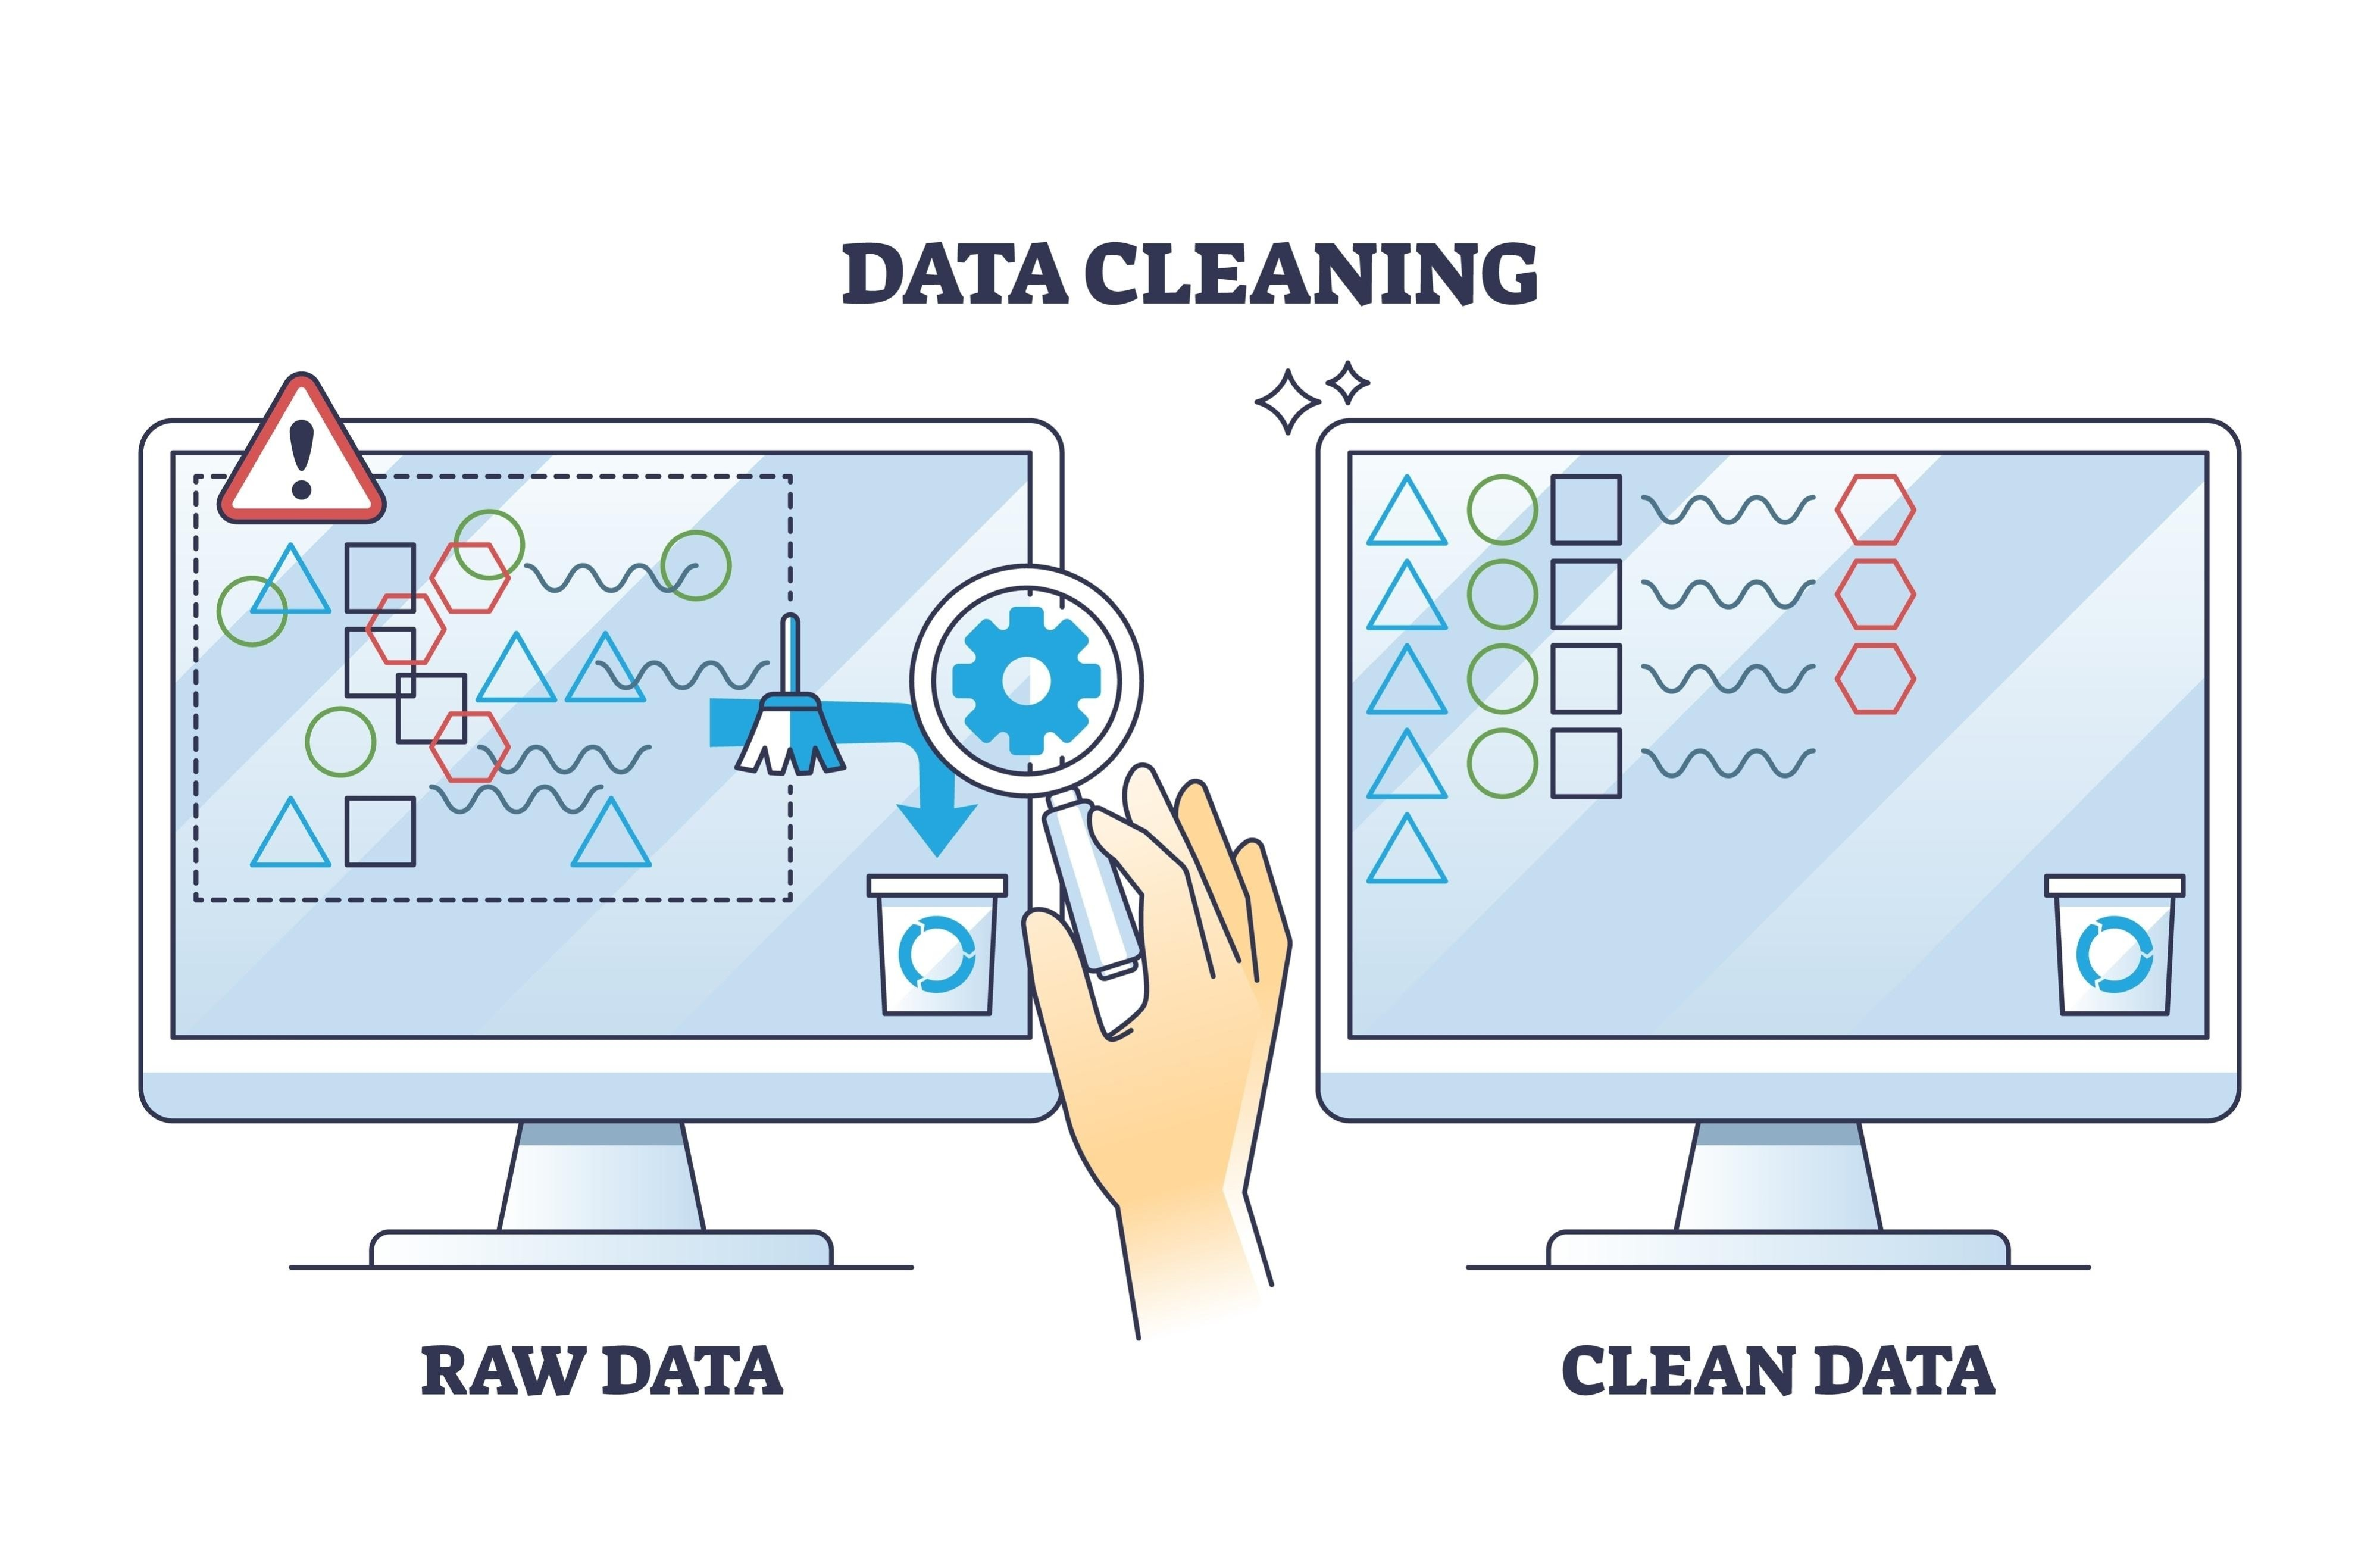

### 🚀 3.1. Tratamiento de Valores Nulos
Para garantizar que el análisis sea estadísticamente significativo y técnicamente eficiente, se han aplicado las siguientes reglas de procesamiento sobre el dataset del Censo 2022:

Identificar las columnas que presentan más del 30 % de valores nulos para decidir su eliminación.
En el caso de columnas críticas con pocos valores faltantes, se realiza la imputación de datos.

El código **analiza los valores nulos**, elimina las columnas con **más del 30 % de datos faltantes** y muestra un **comparativo del número de columnas antes y después** del proceso de limpieza.


In [ ]:
# Obtiene el número total de columnas del DataFrame original
total_columnas_antes = df.shape[1]
total_columnas_antes  # Muestra el total de columnas antes del tratamiento

# Calcula el porcentaje de valores nulos por cada columna
nulos = (
    df.isna()          # Identifica valores nulos (NaN)
      .mean()          # Calcula la proporción de nulos por columna
      .mul(100)        # Convierte la proporción a porcentaje
      .round(2)        # Redondea a 2 decimales
      .reset_index()   # Convierte el índice en una columna
)

# Renombra las columnas del DataFrame resultante
nulos.columns = ['Columna', 'Porcentaje_nulos']

# Selecciona las columnas que tienen más del 30% de valores nulos
columnas_mayor_30 = (
    nulos[nulos['Porcentaje_nulos'] > 30]['Columna']
    .tolist()          # Convierte los nombres de columnas a una lista
)

# Elimina del DataFrame las columnas con más del 30% de nulos
df_reducido = df.drop(columns=columnas_mayor_30)

# Obtiene el total de columnas después de eliminar las columnas con muchos nulos
total_columnas_despues = df_reducido.shape[1]
total_columnas_despues  # Muestra el total de columnas después del tratamiento

# Crea un DataFrame resumen con el antes y después del tratamiento de columnas
resumen_columnas = pd.DataFrame({
    'Estado': ['Antes del tratamiento', 'Después del tratamiento'],
    'Total_columnas': [total_columnas_antes, total_columnas_despues]
})

# Muestra el resumen final
resumen_columnas


,Estado,Total_columnas
0,Antes del tratamiento,36
1,Después del tratamiento,18


Luego de validar, nos dimos cuenta que necesitaremos la columna "numerodecuartos" por ello se llenará esa pero se eliminara la columna "numerodehogares"

### Filtrado por Umbral de Nulos (30%)
Se decidió eliminar automáticamente cualquier columna que presentara más del 30% de valores ausentes.
###¿Por qué?:
Una columna con un alto índice de nulos introduce sesgos y reduce la confiabilidad de cualquier modelo o gráfico. Al superar el 30%, la cantidad de datos "inventados" o imputados necesarios para rellenar los huecos deformaría la realidad estadística de la población ecuatoriana.

### Reducción de Dimensionalidad
El paso de total_columnas_antes a total_columnas_despues no es solo una limpieza, es una optimización.
### ¿Por qué?:
Trabajar con un DataFrame más ligero permite que las operaciones en Python sean más rápidas y que el enfoque del análisis se mantenga en las variables que realmente tienen información completa y útil (como acceso a servicios básicos o ubicación).

In [ ]:
# Luego de validar, nos dimos cuenta que necesitaremos la columna "numerodecuartos" por ello se llenará esa pero se eliminara la columna "numerodehogares"

df['v15_numerodecuartos'] = (
    df['v15_numerodecuartos']
        .fillna(df['v17_numerodehogares'].mean())
        .abs()
)

if 'v17_numerodehogares' in df.columns:
  df = df.drop(columns=['v17_numerodehogares'])

# Convertimos a entero la columna numerodehogares

df['v15_numerodecuartos'] = df['v15_numerodecuartos'].astype(int)

# Como punto adicional agregaremos un metodo que rellene las columnas que pretendiamos eliminar por la media

for col in columnas_mayor_30:
  if col != 'v17_numerodehogares':
    df[col] = df[col].fillna(df[col].mean())
    df[col] = df[col].astype(int)

# Tambien rellenaremos las columans que esten menor al 30%

for col in df.columns:
  if df[col].isna().sum() > 0:
    df[col] = df[col].fillna(df[col].mean())
    df[col] = df[col].astype(int)
# Validamos los datos con su descripción

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 35 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   i01_provincia         1000000 non-null  object
 1   i02_identificadordec  1000000 non-null  object
 2   i03_identificadordep  1000000 non-null  object
 3   i04_zona              1000000 non-null  object
 4   i05_sector            1000000 non-null  object
 5   i10_numerodevivienda  1000000 non-null  object
 6   d01_tipodevia         1000000 non-null  int64 
 7   v01_tipodevivienda    1000000 non-null  int64 
 8   v0201_condiciondeocu  1000000 non-null  int64 
 9   v0202_condiciondeocu  1000000 non-null  int64 
 10  v03_materialpredomin  1000000 non-null  int64 
 11  v04_estadodeltechooc  1000000 non-null  int64 
 12  v05_materialpredomin  1000000 non-null  int64 
 13  v06_estadodelaspared  1000000 non-null  int64 
 14  v07_materialpredomin  1000000 non-null  int64 
 15 

Revisamos el conteo de valores que tiene actualmente la columna de numerodecuartos, luego de la imputación lógica

In [ ]:
# Generamos el conteo, lo ordenamos por el número de cuartos (el índice) y reseteamos para tener un DataFrame
tabla_cuartos = df['v15_numerodecuartos'].value_counts().sort_index().reset_index()

# Renombramos las columnas para que sean claras
tabla_cuartos.columns = ['Número de Cuartos', 'Cantidad de Viviendas']

# Agregamos el porcentaje para un mejor análisis
tabla_cuartos['Porcentaje'] = (tabla_cuartos['Cantidad de Viviendas'] / tabla_cuartos['Cantidad de Viviendas'].sum() * 100).round(2)

# Mostramos la tabla con un diseño profesional (Barras de datos y formato de porcentaje)
print("Validación de Frecuencias: Columna 'v15_numerodecuartos'")
display(tabla_cuartos.style.bar(subset=['Cantidad de Viviendas'], color='#3498db')
                     .format({'Porcentaje': '{:.2f}%'})
                     .hide(axis='index'))

Validación de Frecuencias: Columna 'v15_numerodecuartos'


Número de Cuartos,Cantidad de Viviendas,Porcentaje
1,404483,40.45%
2,134747,13.47%
3,170898,17.09%
4,143767,14.38%
5,83210,8.32%
6,37817,3.78%
7,13489,1.35%
8,6617,0.66%
9,2308,0.23%
10,1516,0.15%


# 4️⃣ Fase 4: Transformación y Procesamiento de Datos

## 🚀 4.1.  Agrupamiento de columnas:

Vamos a crear una nueva columna que es el promedio de cuartos por provincia que nos puede servir para visualizarlo mas tarde.

In [ ]:
# Agrupamiento y cálculo del promedio
# Convertimos el resultado directamente a un DataFrame para mejor manejo
cuartos_por_prov = (
    df.groupby('i01_provincia')['v15_numerodecuartos']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

# Renombramos las columnas para que sean claras en el reporte
cuartos_por_prov.columns = ['Provincia', 'Promedio_Dormitorios']

# Visualización con Estilo (Heatmap y redondeo)
print("Ranking de Provincias por Promedio de Dormitorios:")
display(cuartos_por_prov.style.format({'Promedio_Dormitorios': '{:.2f}'})
                     .background_gradient(cmap='YlGnBu', subset=['Promedio_Dormitorios'])
                     .set_caption("Este análisis permite identificar el tamaño promedio de las viviendas por región."))

Ranking de Provincias por Promedio de Dormitorios:


,Provincia,Promedio_Dormitorios
0,AZUAY,2.83
1,CARCHI,2.66
2,CAÑAR,2.55
3,CHIMBORAZO,2.47
4,COTOPAXI,2.44
5,BOLÍVAR,2.38


## 🚀 4.2.  Filtro de viviendo en zona rural:

Otro analisis que puede ser interesante es el deficit habitacional por zona rural que nos puede decir si existe escases de viviendas en el sector para el tamaño de la población

In [ ]:
# Realizamos el filto de deficit habitacional por zona rural
# Colocamos el valor de 1 en el diccionario de datos significa Dignas o aceptables
# Colocamos 2 en areaurnaorural porque es el valor que nos pone el diccionario de datos
filter_zone = df[
    (df['def_hab_deficithabit'] == 1 ) &
    (df['aur_areaurbanaorural'] == 2)
]

# Ordenamos los datos de forma descendente por el nunmero de cuartos
filter = filter_zone.sort_values(by='v15_numerodecuartos', ascending=True)

# Visualizamos el resultado del filtro
print(f' Filto de deficit por zona rural {filter.info()}')

<class 'pandas.core.frame.DataFrame'>
Index: 330721 entries, 600391 to 530078
Data columns (total 35 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   i01_provincia         330721 non-null  object
 1   i02_identificadordec  330721 non-null  object
 2   i03_identificadordep  330721 non-null  object
 3   i04_zona              330721 non-null  object
 4   i05_sector            330721 non-null  object
 5   i10_numerodevivienda  330721 non-null  object
 6   d01_tipodevia         330721 non-null  int64 
 7   v01_tipodevivienda    330721 non-null  int64 
 8   v0201_condiciondeocu  330721 non-null  int64 
 9   v0202_condiciondeocu  330721 non-null  int64 
 10  v03_materialpredomin  330721 non-null  int64 
 11  v04_estadodeltechooc  330721 non-null  int64 
 12  v05_materialpredomin  330721 non-null  int64 
 13  v06_estadodelaspared  330721 non-null  int64 
 14  v07_materialpredomin  330721 non-null  int64 
 15  v08_estadodelpiso

## 🚀 4.3.  Comprobaremos si tiene los servicios basicos completos:

Un analisis interesante es validar si tiene servicios básicos en la poblacion

In [ ]:
# Definición de la variable derivada: Servicios Básicos Completos
# Consideramos completo si: Agua por red pública, frecuencia diaria, pozo séptico/alcantarillado y uso exclusivo.
df['servicios_completos'] = (
    (df['v09_elaguaquerecibel'] == 1) &
    (df['v10_elaguaquerecibel'].isin([1, 2])) &
    (df['v11_elserviciohigien'] == 1) &
    (df['v12_disponibilidadde'] == 1)
).map({True: 'Acceso Completo', False: 'Acceso Limitado'})

# Resumen estadístico del hallazgo
resumen_servicios = df['servicios_completos'].value_counts().reset_index()
resumen_servicios.columns = ['Estado de Servicios', 'Total de Viviendas']

# Cálculo de porcentaje para el Insight
resumen_servicios['Porcentaje'] = (resumen_servicios['Total de Viviendas'] / resumen_servicios['Total de Viviendas'].sum() * 100).round(2)

print("Resumen de Calidad de Servicios Básicos en Ecuador:")
display(resumen_servicios.style.format({'Porcentaje': '{:.2f}%'}).bar(subset=['Porcentaje'], color='#5fba7d'))

Resumen de Calidad de Servicios Básicos en Ecuador:


,Estado de Servicios,Total de Viviendas,Porcentaje
0,Acceso Completo,708597,70.86%
1,Acceso Limitado,291403,29.14%


## 🚀 4.4.  Tabla de viviendas por provincia y area urbana/rural:

Un analisis de las viviendas por provincia y area

In [ ]:
# 1. Creamos la tabla pivote
# Nota: Usamos 'count' para contar el número de viviendas por área
tabla_pivot_area = pd.pivot_table(
    df,
    values='id_viv_identificador',
    index='i01_provincia',
    columns='aur_areaurbanaorural',
    aggfunc='count'
).fillna(0).astype(int)

# 2. Renombramos las columnas con el diccionario correcto
tabla_pivot_area = tabla_pivot_area.rename(
    columns={1: 'Urbana', 2: 'Rural'}
)

# 3. Agregamos una columna de 'Total' para dar un mejor insight
tabla_pivot_area['Total'] = tabla_pivot_area['Urbana'] + tabla_pivot_area['Rural']

# 4. Mejoramos la visualización con estilo de Pandas
print("Distribución de Viviendas por Área (Urbana/Rural) y Provincia:")
display(tabla_pivot_area.style.background_gradient(cmap='Greens', subset=['Urbana', 'Rural']))

Distribución de Viviendas por Área (Urbana/Rural) y Provincia:


aur_areaurbanaorural,Urbana,Rural,Total
i01_provincia,,,
AZUAY,172559,180273,352832
BOLÍVAR,29503,58005,87508
CARCHI,32514,32066,64580
CAÑAR,45148,64452,109600
CHIMBORAZO,97071,95314,192385
COTOPAXI,65759,127336,193095


## 🚀 4.5.  Promedio de cuartos por provincia y tipo de vivienda

In [ ]:
# Configuramos Pandas para que muestre TODAS las columnas y no fragmente la tabla
pd.set_option('display.max_columns', None)  # Muestra todas las columnas
pd.set_option('display.expand_frame_repr', False) # Evita que la tabla se rompa en bloques

tipo_vivienda_dict = {
    1: "Casa/villa", 2: "Dep. Edificio", 3: "Cuarto Inquilinato", 4: "Mediagua",
    5: "Rancho", 6: "Covacha", 7: "Choza", 8: "Otra Particular",
    9: "Hotel/Hostal", 10: "Cuartel", 11: "Cárcel", 12: "Hospital",
    13: "Religiosa", 14: "Centro Niños", 15: "Asilo", 16: "Internado",
    17: "Campamento", 18: "Otra Colectiva", 19: "Sin vivienda"
}

# Creación de la tabla pivote
cuartos_por_prov_tipo_viv = pd.pivot_table(
    df,
    values='v15_numerodecuartos',
    index='i01_provincia',
    columns='v01_tipodevivienda',
    aggfunc='mean'
).fillna(0).astype(int)

# Renombramos las columnas
cuartos_por_prov_tipo_viv = cuartos_por_prov_tipo_viv.rename(columns=tipo_vivienda_dict)
from IPython.display import display

print("Análisis de Dormitorios por Provincia y Tipo de Vivienda:")
display(cuartos_por_prov_tipo_viv.style.set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('color', 'black'), ('font-weight', 'bold')]}]
))

Análisis de Dormitorios por Provincia y Tipo de Vivienda:


v01_tipodevivienda,Casa/villa,Dep. Edificio,Cuarto Inquilinato,Mediagua,Rancho,Covacha,Choza,Otra Particular,Hotel/Hostal,Cuartel,Cárcel,Hospital,Religiosa,Centro Niños,Asilo,Internado,Campamento,Otra Colectiva,Sin vivienda
i01_provincia,,,,,,,,,,,,,,,,,,,
AZUAY,3,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
BOLÍVAR,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1
CARCHI,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
CAÑAR,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1
CHIMBORAZO,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
COTOPAXI,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [ ]:
# Importacion de librerias para graficar
import matplotlib.pyplot as plt
import seaborn as sns

# 5️⃣ Fase 5: Análisis y Presentación de Insights Preliminares

Basándose en las transformaciones realizadas, extraer al menos un insight inicial.

Responder a una pregunta simple sobre los datos, apoyándose en los resultados
de las transformaciones.
Ejemplo: "¿Cuál es el día de la semana con el gasto promedio más alto?", "¿Qué
ciudad tiene la mayor cantidad de usuarios en la API?", "¿Cuál es la temperatura
promedio máxima en la semana para Quito?".
2. Mostrar el resultado de manera clara (ej. una tabla, un texto explicativo).
3. Mostrar dos gráficos y la interpretación de estos.


En nuestro proyecto tenemos las siguientes transformaciones:

- ¿Qué provincias presentan mayor y menor tamaño promedio de vivienda medido por número de cuartos?
- ¿Cuál es el nivel de déficit habitacional en las zonas rurales y cómo se distribuye territorialmente?
- ¿Tiene servicios básicos?
- ¿Cómo se distribuyen las viviendas entre zona urbana y rural en cada provincia?
- ¿Cómo varía el tamaño promedio de las viviendas (en número de cuartos) según el tipo de vivienda y la provincia?

## 🚀 5.1. ¿Qué provincias presentan mayor y menor tamaño promedio de vivienda medido por número de cuartos?

Según el promedio que obtuvimos anteriormente vamos a graficarlo y sacar conclusiones.

<Figure size 1200x600 with 0 Axes>

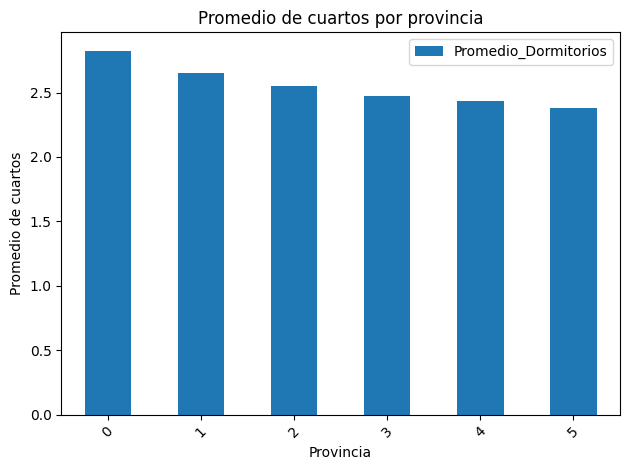

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

cuartos_por_prov.plot(kind='bar')

plt.title('Promedio de cuartos por provincia')
plt.xlabel('Provincia')
plt.ylabel('Promedio de cuartos')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### 🧠 Interpretación

Por el grafico de barras notamos que la provincia del Azuy tiene mayor promedio de cuartos por habitación, eso quiere decir que hay casas con mas habitaciones que el resto de provincias. Puede tambien significar que las casas son mas grandes y que tienden a construir para aumentar sus habitaciones y por ende también la cantidad de personas que habitan la misma.

Sin embargo, se puede interpretar que tienen habitaciones para otros oficios como entretenimiento, almacenaje u otro motivo pero eso no nos dice el gráfico. La variación entre provincias esta entre 2.4 y 2.8 que es algo homogenea entre las provincias.

Tenemos buena estabilidad de vivienda en esas provincias según el grafico donde Bolívar con menor promedio solo indica que tiene viviendas más pequeñas que pueden interpretarse como diferencias socioeconomicas, viviendas muy básicas, etc.

En conclusión a la pregunta, Azuay es la que tiene mayor promedio y la menor es Bolívar.

## 🚀 5.2. ¿Cuál es el nivel de déficit habitacional en las zonas rurales y cómo se distribuye territorialmente?

Según el por el deficit habitacional que hicimos anteriormente vamos a realizar una analisis.

In [ ]:
# Calculamos el déficit habitacional rural por provincia
deficit_rural = (
    df[
        (df['def_hab_deficithabit'] == 1) &
        (df['aur_areaurbanaorural'] == 2)
    ]
    .groupby('i01_provincia')
    .size()
    .reset_index(name='Cantidad_Viviendas_Deficit') # Convertimos a DataFrame con nombre claro
    .sort_values(by='Cantidad_Viviendas_Deficit', ascending=False)
)

# 2. Visualización mejorada
print("Provincias con mayor Déficit Habitacional en el Sector Rural:")
display(deficit_rural.style.bar(subset=['Cantidad_Viviendas_Deficit'], color='#FFA07A')
                     .set_caption("Análisis de vulnerabilidad habitacional rural"))

Provincias con mayor Déficit Habitacional en el Sector Rural:


,i01_provincia,Cantidad_Viviendas_Deficit
0,AZUAY,113066
5,COTOPAXI,78367
4,CHIMBORAZO,58489
3,CAÑAR,40016
1,BOLÍVAR,26324
2,CARCHI,14459


<Figure size 1000x600 with 0 Axes>

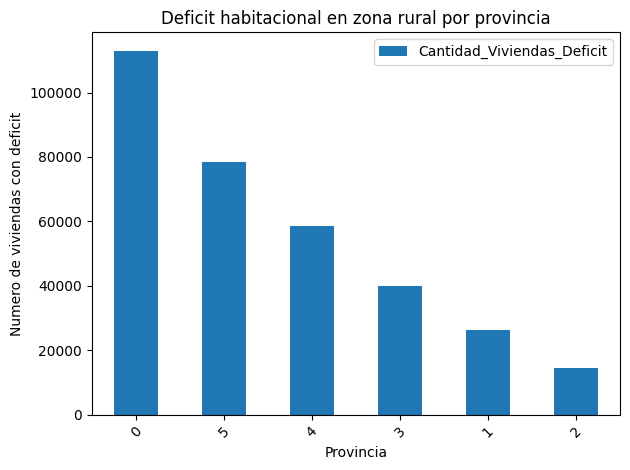

In [ ]:
# Luego graficamos este deficit

plt.figure(figsize=(10,6))

deficit_rural.plot(kind='bar')

plt.title('Deficit habitacional en zona rural por provincia')
plt.xlabel('Provincia')
plt.ylabel('Numero de viviendas con deficit')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### 🧠 Interpretación

El gráfico de barras nos muestra el déficit habitacional por provincua que significa que hay mas población rural en la población. En Azuay se ve más condiciones de vivienda rural en la provincia. La concentración de la población rural que provoca calidad de vida menor o también puede significar menor disponibilidad de necesidades básicas como los servicios básicos, salud, alimentación, pero eso analizaremos luego.

En la provincia de Cotopaxi como segundo lugar tenemos algo similar que Azuay sin embargo en las provincias de Bolívar y Carchi se ve una disminución de la población rural.

Exiten varis factores dentro de este deficit pero no es un indice que se pueda medir con criterio profesional, es una forma de ver la población en las provincias que nos puede responder preguntas de la población rural en el país.

## 🚀 5.3. ¿Tienen servicios básicos?

En base la nueva columna que creamos anteriormente revisaremos que resultados nos da.

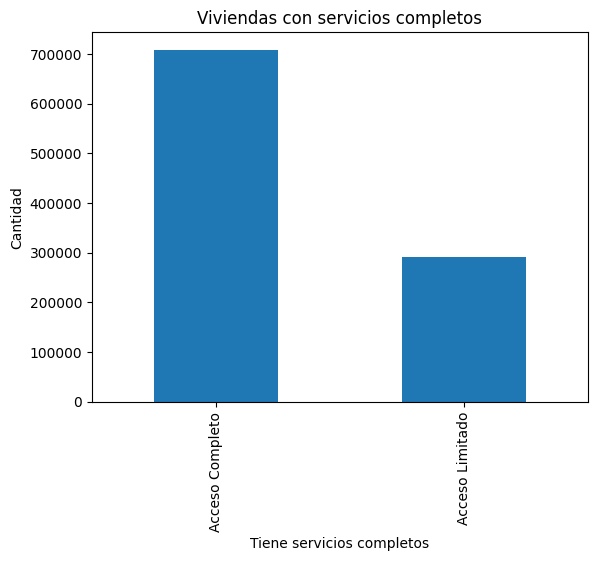

In [ ]:
# Gráficamos el resultado
df['servicios_completos'].value_counts().plot(kind='bar')
plt.title('Viviendas con servicios completos')
plt.xlabel('Tiene servicios completos')
plt.ylabel('Cantidad')
plt.show()


### 🧠 Interpretación

En este gráfico nos muestra que al menos 610 mil viviendas no tiene servicios y eso es preocupante. Sin embargo, vamos a validarlo por provincia.

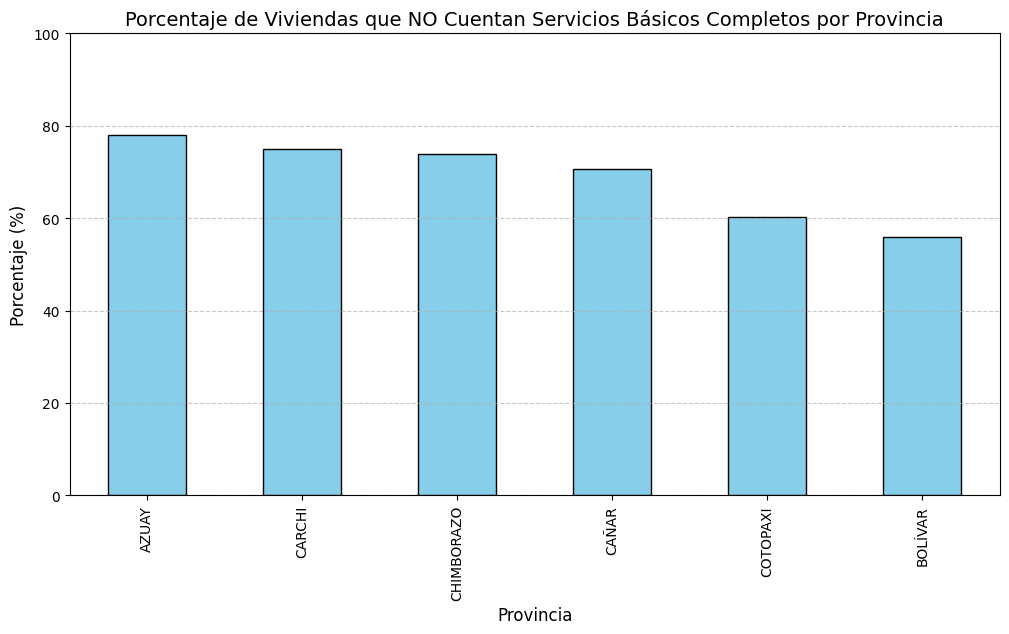

In [ ]:
# Calculamos el promedio usando una lógica booleana rápida (True=1, False=0)
# Esto permite que el .mean() funcione y nos dé el porcentaje directamente
servicios_prov = (
    (df['servicios_completos'] == 'Acceso Completo') # Volvemos a evaluar como booleano
    .groupby(df['i01_provincia'])
    .mean()
    .sort_values(ascending=False) * 100
)

# Mejoramos el gráfico (añadiendo títulos y colores)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
servicios_prov.plot(kind='bar', color='skyblue', edgecolor='black')

# Añadimos etiquetas
plt.title('Porcentaje de Viviendas que NO Cuentan Servicios Básicos Completos por Provincia', fontsize=14)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Provincia', fontsize=12)
plt.ylim(0, 100) # El eje Y siempre debe ir de 0 a 100 para porcentajes
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

En este gráfico mas descriptivo tenemos que Carchi es la provincia con menor disponibilidad a servicios básicos que tenemos en este dataset. La provincia andina no es muy grande pero esto llega a tener alarmas por la cantidad de indisponiblidad de algo tan básico.


Sin embargo, consideremos que este gráfico tiene tres varibles que son la dispibilidad del agua, el acceso energía electrica y servicios higienicos. Esto llega a ser muy varible porque puede ser que tengan acceso alguna de las variables anteriores pero por no disponer alguna ya se vuelve una estadistica erronea. Considerar que exiten varias opciones en cada una de esas variables que si hacemos una analisis mas detallado podremos depurar este sesgo de resultados que es muy estricto a la agrupación inicial.


En conclusión, a partir de la tranformación realizada tenemos un resultado de que existe almenos 60% del dataset no tiene servicio básico donde principalmente Carchi y Azuay. Sin embargo, las varibles usadas para esa agrupación no determinan que sea la realidad porque existen muchas variables en cada columna que pueden interpretarse como si dispongan pero estamos siendo muy espcificos que puede causar una mala interpretación.

## 🚀 5.4. ¿Cómo se distribuyen las viviendas entre zona urbana y rural en cada provincia?

En base a la tabla de vivienda por provincia y area urbana/rural tenemos el siguiente gráfico:


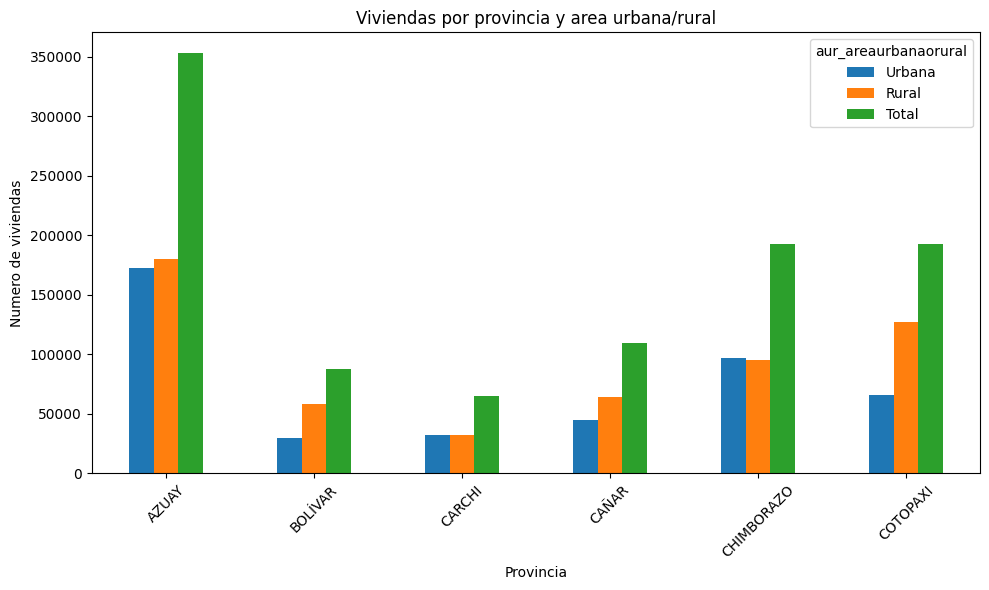

In [ ]:
# Crearemos el gráfico a partir de la tabla creada anteriormente

tabla_pivot_area.plot(kind='bar', figsize=(10,6))

plt.title('Viviendas por provincia y area urbana/rural')
plt.xlabel('Provincia')
plt.ylabel('Numero de viviendas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 🧠 Interpretación

Segun el gráfico de barras tenemos una afirmación del análisis anteriormente realizado.

En la provincia de Azuay lidera la población rural respecto a la urbana mientras que Chimborazo es todo lo contrario donde la urbana es ligeramente dominante a la rural. Esto nos hace entender que descartando Chimborazo y Carchi el resto de provincias es dominante la población rural y da interpretación que su fuente de ingresos más probable es lo asociado a la agricultura y ganaderia.


Las condiciones rurales pueden ser favorables para esta población en un analisis mas profundo de acuerdo a las variables pero esto puede interpretarse como un sector productivo del país.

## 🚀 5.5. ¿Cómo varía el tamaño promedio de las viviendas (en número de cuartos) según el tipo de vivienda y la provincia?

En base al promedio de cuartos por provincia y tipo de vivienda tenemos el siguiente gráfico:


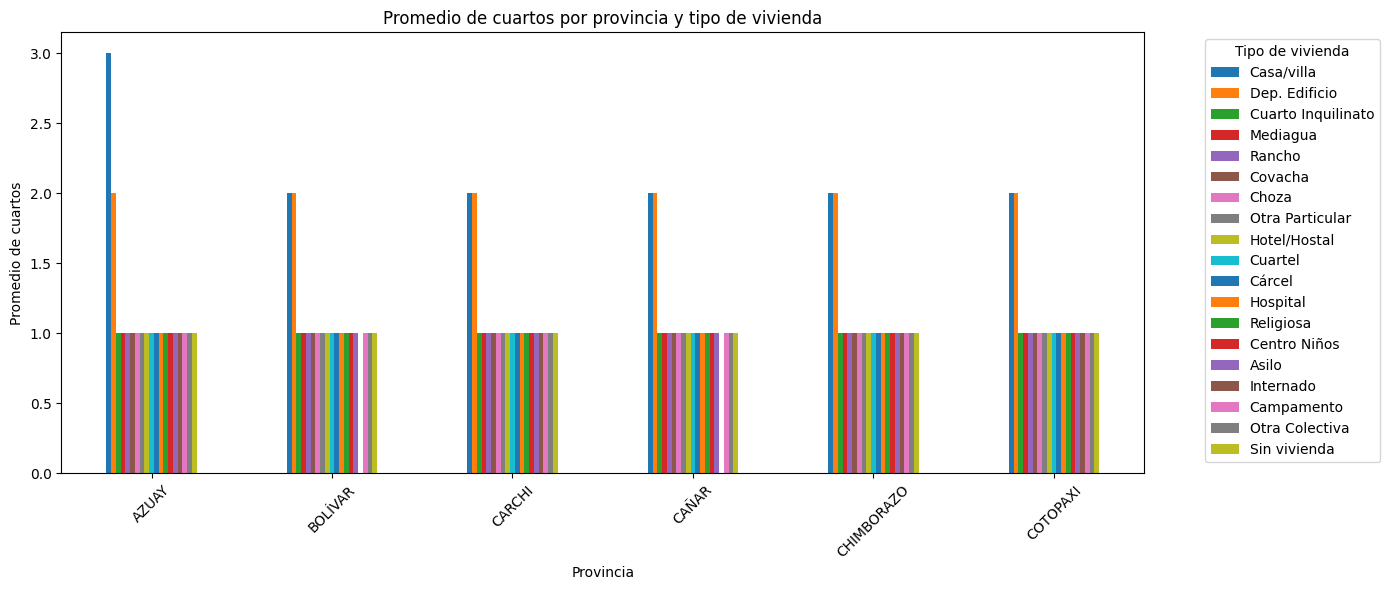

In [ ]:
# Graficamos la tabla pivot del promedio

cuartos_por_prov_tipo_viv.plot(kind='bar', figsize=(14,6))

plt.title('Promedio de cuartos por provincia y tipo de vivienda')
plt.xlabel('Provincia')
plt.ylabel('Promedio de cuartos')
plt.xticks(rotation=45)
plt.legend(title='Tipo de vivienda', bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.show()


### 🧠 Interpretación

Segun el gráfico de barras tenemos que el tipo de vivienda que mas prediminan son las casas sobre todo en la provincia del Azuay

En el resto de provincias tenemos una similitud en el resto de categorias de que almenos existe una de ese tipo de residencias que causa algo de confusion sobre la ruralidad. La cantidad limitada de las mismas puede ser clave para interpretar y continuar la afirmación de que es mas predominante la población rural.

Los departamentos en edificios entran tambien como punto fuerte en las provincia que hace entender que exite edificios de mas de 5 pisos para tener departamentos de arriendo.

En conclusión, tenemos que pueden existir edificios con departamentos disponibles para alquiler como vivienda y casas habitables donde las personas tiene muchas habitaciones segun los datos anteriores en la provincia del Azuay.

# 6️⃣  Fase 6: Conclusiones del proceso y análisis de datos

Agregue sus conclusiones, desarrollando un análisis integral de todo el proceso realizado.
En su reflexión, identifique y explique:
- ¿Qué aspectos del proceso fueron más aplicables o efectivos?
- ¿Cuáles fueron los elementos más complejos o desafiantes?

Sustente sus respuestas con argumentos claros y, de ser posible, con ejemplos derivados de su experiencia durante el desarrollo de la actividad.

## 🚀 6.1. ¿Qué aspectos del proceso fueron más aplicables o efectivos?


## ⭐ Respuesta

A nuestra opinión fue la extracción de los datos de una fuente del gobierno que es usada en estudios para los GAD. Esta información que permite evaluar diferentes aspectos de la población nos da más resultados de interpretación de algo tan concreto como el censo poblacional. La tendencia de predicción de estos resultados pueden ser ambigua pero cercana a la realidad si tuvieramos que realizarlo.

La información es desafiante de contruir porque tiene muchas variables que si no se realizan correctamente pueden provocar un error en los resultados de la transformación que quisieramos concluir. Se aprovecho el uso del dataset bastante variado y muy bien documentado para usarlo en este proyecto.

Tener la información muy bien documentada puede sesgar errores a futuro para realizar un analisis mas exhaustivo y preciso.



## 🚀 6.2. ¿Cuáles fueron los elementos más complejos o desafiantes?


## ⭐ Respuesta

El mayor reto fue escoger el conjunto de datos de la fuente que escogimos. El mayor conjunto de datos que existe es de 16 millones para el censo poblacional y nostros solo usamos una fracción del mismo para este trabajo. Además, el nivel de procesamiento de Colab tiene un limite y por eso tambien se limitó el conjunto de datos que disponiamos.

Las varibales que existen en cada columna del dataset, es decir, las opciones que tiene cada columna estan asociadas a un número pero luego se entiende como un dato mas cualitativo que cuantitativo y causa mucha confusión. Documentarse bien en la fuente oficial para resolver esas dudas ayudo mucho pero el tiempo fue limitado para este trabajo y se necesito extraer ciertos datos claves para el analisis final como las provincias, cantones, parroquias y las viviendas.

# 7️⃣ Fase 7: Aplicación al entorno profesional

## 🚀 Redacta una sección final de aplicación:
- Cada miembro del equipo colocara su nombre una explicación de como aplicaría
lo aprendido en esta semana en su entorno profesional.

# 🖥️ **Christian Carrera**

En mi trabajo no tengo mucho que sacar interpretaciones de datos pero si realizo mucho los pivots de datos de acuerdo a una base de datos. Este nuevo aprendizaje ayuda aprender criterios para realizarlo mas que la programación en si. Puedo aplicarlo en la creación de historias de usuario como en la evaluación critica del equipo a nivel de conocimiento.


En mi opinión esto me serviria más si tendria que evaluar datos a nivel de negocio lo cual casi no estoy involucrado. Pero el uso de python como lenguaje y el resto de funciones me ayudará mucho más en mi ejercicio profesional.

# **Alexander Luna**

Como desarrollador de software en el Registro de la Propiedad y Mercantil de Rumiñahui, este nuevo ejercicio con datos del INEC me aporta herramientas críticas para la estandarización de bases de datos masivas. La implementación de diccionarios para el mapeo de variables y la limpieza de valores nulos son directamente aplicables a la depuración de folios reales y registros catastrales, el análisis de la composición de viviendas mediante Python me permitirá desarrollar módulos de consulta más eficientes, mejorando la precisión en la clasificación de predios y apoyando la toma de decisiones basada en la realidad demográfica actualizada del cantón.

# **Romel Cerna**

Lo aprendido esta semana es altamente aplicable a mi rol como soporte de aplicaciones bancarias, ya que me permite consumir y validar APIs, analizar respuestas JSON y detectar errores de forma más rápida y precisa. El uso de pandas para limpiar y explorar datos facilita el análisis de logs y reportes operativos, ayudando a identificar inconsistencias y valores faltantes, mediante filtrado, agrupamiento y visualización de datos, puedo obtener insights relevantes, como patrones recurrentes de errores, aplicaciones con mayor incidencia o periodos de mayor impacto operativo. Estos insights permiten pasar de un soporte reactivo a uno más analítico y preventivo, aportando información clara para la toma de decisiones y la mejora continua de las aplicaciones.